# 22장 시퀀스 배열로 다루는 순환 신경망

## 1. LSTM을 이용한 로이터 뉴스 카테고리 분류하기

1.1.) 인공지능이 문장을 듣고 이해한다 = 이미 많은 문장을 **학습**해놓았다는 뜻.

1.2.) 문장의 학습이란, **과거의 입력된 데이터와 나중에 입력된 데이터와의 관계를 고려**해야 하는 문제.. => 이를 위해서 순환 신경망 (Recurrent Neural Network, RNN)이 나옴.

1.3.) **순환 신경망** = 앞서 입력받은 데이터를 잠시 기억해놓았다가, 그 기억된 데이터가 얼마나 중요한지 판단하고 별도의 가중치를 주어, 다음 데이터로 넘어가는 것.

= **모든 입력값(x1,x2,x3)이 이 작업을 순서대로 실행하므로**, 다음 층으로 넘어 가기전 같은 층을 맴도는 **순환**의 성질

1.4.)순환되는 것 중 **앞서 나온 입력의 결과가, 뒤에 나오는 입력 값에 영향을 주는 것 !!**


e.g., 입력 1 = 오늘; 입력 2 = 주가

e.g., 입력 1 = 어제; 입력 2 = 주가

둘 다 주가를 물어보는 것이지만, 맨 앞 입력에 따라, 주가 계산 기준이 달라지는 것.

---

2.1.)RNN을 개선하기 위한 **LSTM (Long Short Term Memory) 방법**이 가장 널리 사용되고 있음.

= *순환** 신경망은 한 층 안에서 반복을 많이 해야 하기에, 일반 신경망보다 **기울기 소실 문제**가 더 많이 발생하고, 이를 해결하기 어려운 데, 이를 보완 한 것 임

= 반복되기 직전에 **다음 층으로, 기억된 값을 넘길지 여부를 관리하는 단계를 추가한 것**

###(LSTM은 기억 값의 가중치를 관리하는 장치이다, 그림 22-4)

---

3.1.)RNN은 입력 값과 출력 값을 어떻게 설정하느냐에 따라 다양하게 적용할 수 있다

-다수 입력, 단일 출력 = **문장을 읽고 뜻을 파악할 떄**
[밥은, 먹고, 다니냐] = 안부 인사!

-단일 입력, 다수 출력 = **사진의 캡션을 만들 때**
[퍼그 이미지] = [퍼그, 이불, 요다]

-다수 입력, 다수 출력 = **문장을 번역할 때 활용**
[예, 그게, 다예요] =  [yes, that's, all]

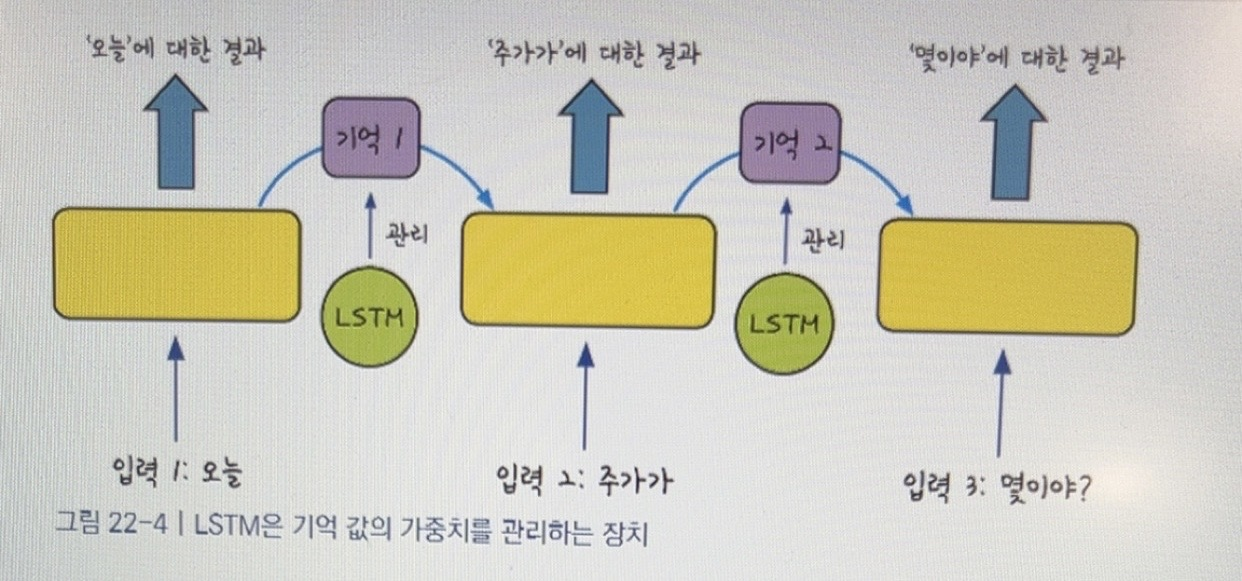

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.datasets import reuters       # 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눕니다.
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=1000, test_split=0.2)
#num_words 라는 인자
##print(X_train[0])을 보면, 단어가 아니라, 빈도수로 나오는 것을 알 수있음
## 빈도가 낮은 단어들까지 다 가져와서 사용하는 것은 비효율적임.
#따라서 num_words = 1000으로 설정하여, 빈도가 1~1000에 해당하는 단어만 선택해서 불어오는 것임


# 데이터를 확인해 보겠습니다.
category = np.max(y_train) + 1 #np.max()는 0부터 세기에 1을 더해서 출려함.
print(category, '카테고리') #46개의 카테고리, 1만여개의 뉴스 기사.
print(len(X_train), '학습용 뉴스 기사')
print(len(X_test), '테스트용 뉴스 기사')
print(X_train[0]) #기사를 출력했지만, 단어가 나오기 보다 오히려 숫자가 나옴 = 이 숫자들은 해당 단어의 빈도수 순서를 의미함
#3 = 세번째로 빈도가 높은 단어라는 뜻
#케라스는 이 작업을 이미 마친 데이터만 불러올 수 있음

46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [ ]:
# 단어의 수를 맞추어 줍니다.
##입력된 기사의 단어 수가 100보다 크면, 100째 단어만 선택하고, 나머지를 버림
##입력된 기사의 단어 수가 100에서 모자랄 때는, 모자라는 부분을 0으로 채움
X_train = sequence.pad_sequences(X_train, maxlen=100)
X_test = sequence.pad_sequences(X_test, maxlen=100)

# 원-핫 인코딩 처리를 합니다.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 모델의 구조를 설정합니다.
model = Sequential()
model.add(Embedding(1000, 100)) #단어 임베딩 설정이 맨 앞에 있어야 함.= 입력이 될 총 단어수 10000, 임베딩 후 출력되는 벡터 크기는 100
model.add(LSTM(100, activation='tanh')) #주로 tanh을 활성화 함수로 사용하는 LSTM
model.add(Dense(46, activation='softmax'))

# 모델의 실행 옵션을 정합니다.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행합니다.
history = model.fit(X_train, y_train, batch_size=20, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

# 테스트 정확도를 출력합니다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.3942 - loss: 2.4546 - val_accuracy: 0.4947 - val_loss: 1.9214
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.5377 - loss: 1.7937 - val_accuracy: 0.5646 - val_loss: 1.7088
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.5798 - loss: 1.6341 - val_accuracy: 0.6135 - val_loss: 1.5531
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6430 - loss: 1.4198 - val_accuracy: 0.6487 - val_loss: 1.4028
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6661 - loss: 1.3057 - val_accuracy: 0.6456 - val_loss: 1.3935
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7087 - loss: 1.1245 - val_accuracy: 0.6710 - val_loss: 1.2695
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7315 - loss: 1.0672 - val_accuracy: 0.6995 - val_loss: 1.1777
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7565 - loss: 0

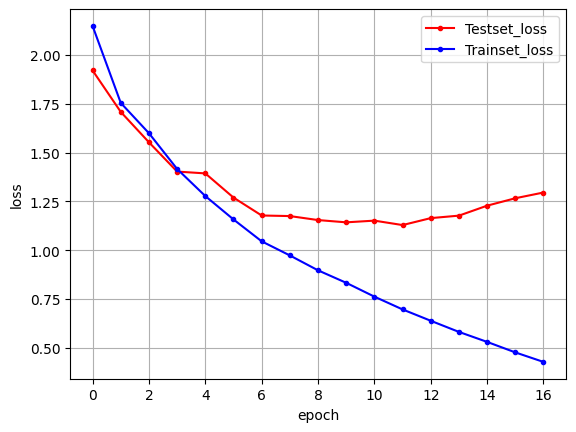

In [ ]:
# 학습셋과 테스트셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 보겠습니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

16번째 에포크에서 학습이 자동 중단, 정확도는 71%

## 2. LSTM과 CNN의 조합을 이용한 영화 리뷰 분류하기

영화 리뷰가 긍정인지 부정인지 구분하는 모델 (클래스는 0/1 두가지 뿐):

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눕니다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 단어의 수를 맞추어 줍니다.
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500) #기사에서 단어 500개까지만 보겠다

#클래스는 0,1 2개 뿐이므로 원-핫 인코딩 불필요

# 모델의 구조를 설정합니다.
model = Sequential()
model.add(Embedding(5000, 100)) #= 입력이 될 총 단어수 5000, 임베딩 후 출력되는 벡터 크기는 100
model.build((None, 500)) ##None은 한 번에 처리할 데이터 묶음의 크기임. None으로 설정해두면 나중에 필요에 따라 자유롭게 바꿀 수 있음
#500 = 한 번에 처리할 단어의 개수 (단어 500개를 하나의 입력단위로 모델이 처리)
model.add(Dropout(0.5)) #과적합 방지를 위해, 전체 뉴런 중 절반을 무작위로 꺼버리는 것
model.add(Conv1D(64, 5, padding='valid', activation='relu',strides=1)) #앞선 CNN의 2D 합성곱을 1차원 형태로 진행하는 것임. #즉, 1차원 줄에서 1차원 커널이 이동하면서 합성곱 레이어를 만드는 것
model.add(MaxPooling1D(pool_size=4)) #1차원 줄의 정해진 구역 안에서 가장 큰 값을 다음 층으로 넘기고 나머지는 버리는 차원 축소
model.add(LSTM(55)) #LSTM 층을 사용하되, 기억 용량 (메모리 셀) 수를 55개로 설정하는 것 = 출력 차원의 크기
model.add(Dense(1)) #출력층은 딱 1개의 숫자로 앞축하여 결론을 내는 것. 긍정/부정이냐를 맞히는 게 아니라, 긍정일 확률만 계산하면 되는 것.
model.add(Activation('sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 496, 64)        │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델의 실행 옵션을 정합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

# 모델을 실행합니다.
history = model.fit(X_train, y_train, batch_size=40, epochs=100, validation_split=0.25, callbacks=[early_stopping_callback])

# 테스트 정확도를 출력합니다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.6876 - loss: 0.5419 - val_accuracy: 0.8862 - val_loss: 0.2857
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9085 - loss: 0.2313 - val_accuracy: 0.8923 - val_loss: 0.2672
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.9378 - loss: 0.1701 - val_accuracy: 0.8962 - val_loss: 0.2654
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.9543 - loss: 0.1327 - val_accuracy: 0.8912 - val_loss: 0.2878
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9635 - loss: 0.1040 - val_accuracy: 0.8830 - val_loss: 0.3264
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9691 - loss: 0.0919 - val_accuracy: 0.8846 - val_loss: 0.3500
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8754 - loss: 0.3733

 Test Accuracy: 0.8760


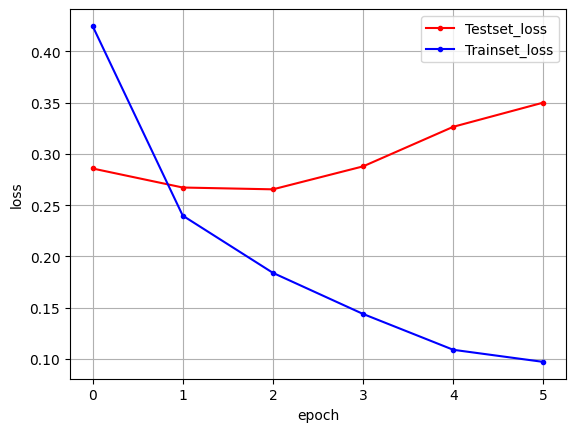

In [ ]:
# 학습셋과 테스트셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 보겠습니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

5번째 에포크에서 종료!, 정확도 87.96%

## 3. Seq2Seq 모델과 어텐션

**Seq2Seq (Sequence-to-Sequence) 모델 개요**

앞서 배운 모델들이 문장을 '이해'하는 데 그쳤다면, Seq2Seq는 이를 바탕으로 새로운 문장을 생성(Generation)하거나 변환하는 모델입니다. (예: 번역기, 챗봇)



---



🏗️ 1. 핵심 구조: 인코더-디코더 (Encoder-Decoder)

--LSTM(또는 RNN) 두 개를 이어 붙인 구조로 이루어져 있습니다.

인코더 (Encoder): "읽는 역할"

--**입력 문장**을 순서대로 읽어들입니다. (**RNN or LSTM 으로 읽음**)

--문장의 의미를 **압축하여 하나의 벡터(Vector)로 만듭니다.**


디코더 (Decoder): "쓰는 역할"

--인코더가 만든 벡터를 넘겨받습니다.

--이를 재료로 삼아 **단어를 하나씩 추론하며 새로운 문장(출력 시퀀스)을 생성**합니다.



---



⚙️ 2. 작동 원리: 문맥 벡터 (Context Vector)

인코더와 디코더를 연결하는 '다리' 역할을 하는 것이 바로 문맥 벡터입니다.

**압축 (Encoding):**

인코더(LSTM)가 문장을 끝까지 읽고 난 후,마지막에 남은 상태 정보 $(h, c)$를 뽑아냅니다.

--**이 $(h, c)$ 묶음을 $'문맥 벡터(Context Vector)'$라고 부르며, 입력 문장의 모든 정보가 요약된 숫자 묶음입니다.

**전송 (Transfer):**

--이 문맥 벡터 $(h, c)$를 디코더의 **첫 번째 시작 상태(Initial State)**로 넣어줍니다.

**생성 (Decoding):**

--디코더는 이 요약 정보를 바탕으로, 소프트맥스(Softmax) 확률을 계산하여 새로운 문장을 조금씩 만들어냅니다.


---


한 줄 요약:

"인코더가 문장을 **숫자 묶음 $(h, c)$**으로 요약해서 던져주면, 디코더가 그것을 받아서 번역문으로 풀어낸다."

###**1. 문맥 벡터로 만드는 원리**

기본 원리: "반죽 섞기" 비유인코더가 문장을 읽는 과정은 마치 밀가루 반죽에 재료를 하나씩 섞는 과정과 같습니다.

공식의 개념:$$\text{오늘의 기억} = \tanh(\text{어제의 기억} + \text{오늘 들어온 단어})$$

여기서 **+ (더하기)**가 바로 정보를 압축하고 섞는 핵심 연산입니다.2. 단계별 수학적 과정 ("I love AI")컴퓨터 내부에서 숫자가 어떻게 변하는지 보겠습니다. (편의상 단순화된 숫자로 예시를 듭니다.)

---

0단계: 준비

초기 상태 ($h_0$): 아무것도 없는 빈 뇌. [0, 0, 0]

---
1단계: "I" 입력

입력 ($x_1$): 'I'라는 단어의 벡터 [1, 0, 0]

연산:$$h_1 = \tanh(h_0 \times W + x_1 \times W)$$(빈 기억에 'I'를 섞음)

결과 ($h_1$): [0.5, 0.1, -0.2] $\rightarrow$ "나(I)"에 대한 정보

---
2단계: "love" 입력

입력 ($x_2$): 'love'라는 단어의 벡터 [0, 1, 0]

연산:$$h_2 = \tanh(h_1 \times W + x_2 \times W)$$(**아까 만든 $h_1$**에 'love'를 추가로 섞음!)

결과 ($h_2$): [0.8, -0.5, 0.3] $\rightarrow$ "나(I) + 사랑(love)"의 짬뽕 정보

---
3단계: "AI" 입력 (마지막)

입력 ($x_3$): 'AI'라는 단어의 벡터 [0, 0, 1]

연산:$$h_3 = \tanh(h_2 \times W + x_3 \times W)$$(**$h_2$**에 'AI'를 마지막으로 섞음)

결과 ($h_3$): [0.9, 0.1, 0.9] $\rightarrow$ "나 + 사랑 + AI" 모든 정보가 압축됨

결론: 마지막에 남은 **$h_3$ 벡터 [0.9, 0.1, 0.9]**가 바로 **문맥 벡터(Context Vector)**입니다.




---



###**2. LSTM의 공식은 조금 더 복잡합니다 (게이트)**

위의 RNN 공식은 단순해서 문장이 길어지면 앞의 내용('I')을 까먹습니다. 그래서 LSTM은 이 공식에 수도꼭지(Gate) 기능을 추가했습니다.

$$\text{최종 기억}(c_t) = (\text{잊을 건 잊기} \times \text{과거 기억}) + (\text{중요한 것만 챙기기} \times \text{현재 단어})$$

삭제 게이트 (Forget Gate): $h_{t-1}$을 보고, 쓸모없는 정보는 지웁니다. (곱하기 0에 가까운 수)

입력 게이트 (Input Gate): $x_t$를 보고, 중요한 정보만 받아들입니다. (곱하기 1에 가까운 수)

이 복잡한 수식들을 거쳐서 **"가장 중요한 정보만 남은 알짜배기 숫자 묶음(h, c)"**이 탄생하는 것입니다.

---

💡 요약

공식: $h_t = f(h_{t-1}, x_t)$

원리: **"이전 단계의 결과물($h_{t-1}$)"**을 버리지 않고, **"이번 단계의 입력($x_t$)"**과 수학적으로(행렬 곱셈) 비벼서 섞어버리는 것입니다.

계속 섞다 보니, 마지막 결과물에는 **앞서 넣은 모든 재료(단어)의 맛(정보)**이 다 배어 있게 됩니다

###**3. 전체 흐름도 (Embedding layer -> Encoder LSTM)**


---


딥러닝 번역기(Seq2Seq)는 이 두 번의 압축 과정을 거칩니다.

**1차 압축 (Embedding Layer):**

"I", "love", "AI" 각각의 단어를 단어 벡터로 변환합니다.

(재료 준비 단계)


---



**2차 압축 (Encoder LSTM):**

준비된 단어 벡터들을 순서대로 읽어서 **하나의 문맥 벡터(Context Vector)**로 뭉칩니다.

(조립 및 완성 단계)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 4.1103 - val_accuracy: 0.0000e+00 - val_loss: 4.1084
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.2500 - loss: 4.0951 - val_accuracy: 0.0000e+00 - val_loss: 4.1007
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5000 - loss: 4.0795 - val_accuracy: 0.0000e+00 - val_loss: 4.0928
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5000 - loss: 4.0629 - val_accuracy: 0.0000e+00 - val_loss: 4.0843
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5000 - loss: 4.0444 - val_accuracy: 0.0000e+00 - val_loss: 4.0749
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5000 - loss: 4.0232 - val_accuracy: 0.0000e+00 - val_loss: 4.0644
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5000 - loss: 3.9985 - val_accuracy: 0.0000e+00 - val_loss: 4.0524
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5000 - loss: 3.9691 - val

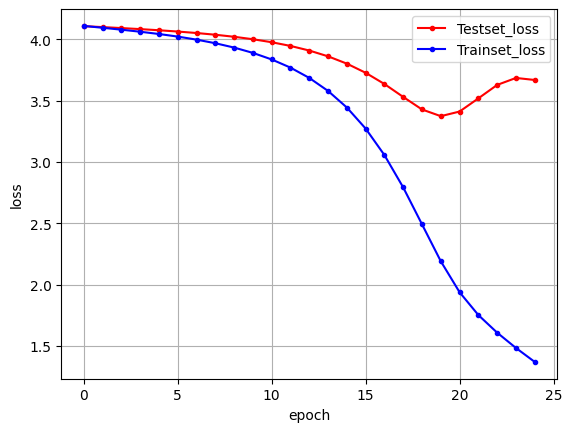

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

#먼저 모델이 이해할 수 있는 형태로 데이터를 전처리하여야 한다 = 자연어 문장을 숫자 시퀀스로 변환하여야 한다.
#실제 구현에서는 방대한 말뭉치 (corpus)를 수집하고, 각 단어에 고유한 인덱스를 부여하기 위해 토크나이징과 인덱싱 과정을 거친다. (이 예제에서는 생략)
# 예제용 데이터셋
# 한국어 입력 (X_data)
# "오늘 날씨 어때"   → [1, 2, 3]
# "오늘 주가 얼마"   → [1, 4, 5]
# "날씨가 점점 따뜻해" → [6, 7, 8]
X_data = [
    [1, 2, 3],
    [1, 4, 5],
    [6, 7, 8]
]

# 영어 출력 (Y_data)
# "It is warm"  → [10, 20, 30]
# "It is high"  → [10, 20, 50]
# "Getting warm" → [60, 30]
Y_data = [
    [10, 20, 30],
    [10, 20, 50],
    [60, 30]
]

# 패딩으로 문장의 길이를 동일하게 맞춘다.
X_train = pad_sequences(X_data, maxlen=5)  # 입력 시퀀스를 길이 5로 맞춤
Y_train = pad_sequences(Y_data, maxlen=4)  # 출력 시퀀스를 길이 4로 맞춤

# 입력 단어 집합 크기와 출력 단어 집합 크기 자동 설정
##모든 단어 인덱스가 범위 안에 들어올 수 있도록, 가장 큰 인덱스를 찾고 거기에 +1
# np.max(X_train)와 np.max(Y_train)을 통해 등장하는 단어의 최댓값(인덱스)를 구한 뒤, +1을 해준다.
input_vocab_size = np.max(X_train) + 1
output_vocab_size = np.max(Y_train) + 1

# 원-핫 인코딩 (출력 데이터용)
y_train = to_categorical(Y_train, num_classes=output_vocab_size)

# 인코더 정의
##인코더는 입력 문장을 숫자 배열로 받아들이고, 이를 벡터로 변환하여 LSTM으로 처리한다.
encoder_inputs = Input(shape=(5,)) #길이 5인 정수 배열을 입력받을 준비를 한다
enc_emb = Embedding(input_dim=input_vocab_size, output_dim=64)(encoder_inputs) #각 정수 (단어 인덱스)를 64차원 벡터로 변환한다.
encoder_lstm = LSTM(128, return_state=True) #이 벡터를 LSTM에 넣으면, LSTM은 문장 첫~끝까지 읽고 그 문장에 대한 기억을 정리해 다음 단계로 넘겨줌
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
#**지금까지의 문맥을 요약한 값 (h), 오랫동안 기억하고 있는 정보를 담은 값 (c)**
##LSTM의 처리 결과 중 문장에 대한 핵심 기억 (h,c)와 함께, **LSTM이 처리하면서 만들어 낸 출력 (encoder_outputs)**도 얻게 됨
###이 각각의 값을 encoder_outputs로, h를 state_h로, c를 state_c로 받아서 encoder_lstm(enc_emb)로 받아준다.
####이런 식으로 인코더 LSTM이 처리한 결과를 모두 받을 수 있다.
####핵심 기억 (h,c)는 디코더에게 전달되어, 디코더가 새로운 문장을 만들 때 활용된다.

# 디코더 정의
##디코더는 인코더가 파악한 문맥 정보를 바탕으로, 새로운 문장을 단어 하나씩 만들어 낸다.
decoder_inputs = Input(shape=(4,)) #길이가 4인 정수 배열을 입력받을 준비를 한다.
dec_emb = Embedding(input_dim=output_vocab_size, output_dim=64)(decoder_inputs) #디코더의 입력 단위 인덱스를 64차원 벡터로 변환 (벡터는 단어의 의미나 특징을 더 풍부하게 담을 수 있다)
decoder_lstm = LSTM(128, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c]) #디코더 LSTM 구동: 인코더의 state_h, state_c를 넣어주었기에, 인코더가 파악한 문장 전체의 의미를 기억한 상태로 시작!
decoder_dense = Dense(output_vocab_size, activation='softmax') #디코더 출력인 decoder_outputs을 확률 분포로 바꿔야 함. #소프트맥스를 통해 모든 단어 후보 중 어떤 단어가 나올 확률이 높은지 최대화할 수 있음
decoder_outputs = decoder_dense(decoder_outputs)

# 모델 구성
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# 모델 컴파일
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
history = model.fit([X_train, Y_train], y_train, batch_size=2, epochs=25, validation_split=0.2)

# 학습 과정 시각화
y_vloss = history.history['val_loss']
y_loss = history.history['loss']
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()


###이러한 Seq2Seq의 근본적인 문제

1.1.)문장이 아무리 길고 복잡하더라도, 결국 **h,c라는 한정된 크기의 숫자 묶음 **하나에 모든 내용을 담아내야 함..

1.2.)**문장이 너무 길거나, 중요한 부분이 문장 앞에 몰려있다면, 이 숫자 묶음 안에 그 모든 정보가 온전히 들어가지 못하는 병목 현상 (bottle neck)임.**

---

2.1.)이러한 병목 현상을 해결하기 위해 등장한, **어텐션 (attention)**

2.2.)디코더가 단어를 결정할 때, 인코더가 처리한 모든 단어 정보를 다시 설펴보고, 그중 현재 단어를 예측하는 데 가장 필요한 부분에 **집중**하도록 하는 로직이다.

2.3.)이를 통해, 디코더는 필요한 정보만 뽑아 쓸 수 있어지면서, 정보의 손실이 줄어들고, 긴 문장/복잡한 문맥도 풍부하게 다룰 수 있게 되었다.

2.4.)어텐션이후로 이를 극대화한 **트랜스포머 (transformer)모델**이 등장함.(챗gpt)